In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score,classification_report

In [72]:
d={"study_hours":[2,4,5,6,None,8,8],"marks":[40,45,34,23,21,43,43],"result":[None,1,1,1,0,0,0]}
df=pd.DataFrame(d)
df

,study_hours,marks,result
0,2.0,40,NaN
1,4.0,45,1.0
2,5.0,34,1.0
3,6.0,23,1.0
4,NaN,21,0.0
5,8.0,43,0.0
6,8.0,43,0.0


In [73]:
df.fillna({"study_hours":df['study_hours'].mean(),'marks':df['marks'].mean(),'result':df['result'].mode()[0]},inplace=True)
df.dropna()
df.drop_duplicates(inplace=True)
df

,study_hours,marks,result
0,2.0,40,0.0
1,4.0,45,1.0
2,5.0,34,1.0
3,6.0,23,1.0
4,5.5,21,0.0
5,8.0,43,0.0


In [74]:
X=df[['study_hours','marks']]
y=df['result']
X,y

(   study_hours  marks
 0          2.0     40
 1          4.0     45
 2          5.0     34
 3          6.0     23
 4          5.5     21
 5          8.0     43,
 0    0.0
 1    1.0
 2    1.0
 3    1.0
 4    0.0
 5    0.0
 Name: result, dtype: float64)

In [75]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train,X_test,y_train,y_test

(   study_hours  marks
 5          8.0     43
 2          5.0     34
 4          5.5     21
 3          6.0     23,
    study_hours  marks
 0          2.0     40
 1          4.0     45,
 5    0.0
 2    1.0
 4    0.0
 3    1.0
 Name: result, dtype: float64,
 0    0.0
 1    1.0
 Name: result, dtype: float64)

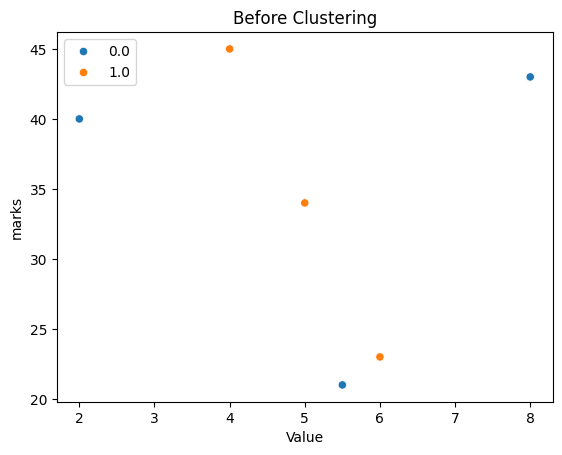

In [99]:
# before clustering
import seaborn as sb
plt.figure()
sb.scatterplot(data=df,x="study_hours",y="marks",hue="result")
plt.title("Before Clustering")
plt.xlabel("Value")
# plt.yticks([])
plt.legend()
plt.show()

In [100]:
wcss=[]
for i in range(1,5):
    kmean=KMeans(n_clusters=i,random_state=42)
    kmean.fit(X)
    wcss.append(kmean.inertia_)

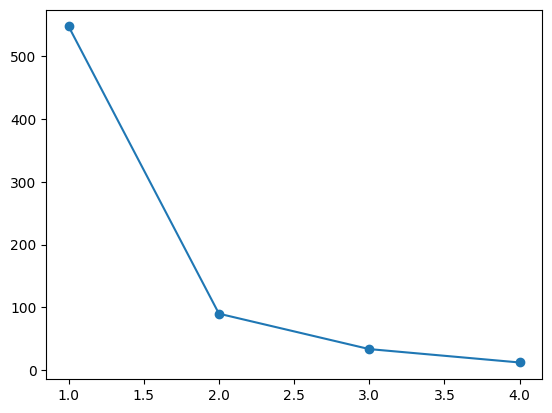

In [101]:
plt.plot(range(1,5),wcss,marker='o')
plt.show()

In [78]:
for k in range(2,4):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    print(f"K:{k} -> {silhouette_score(X, labels):.3f}")

K:2 -> 0.676
K:3 -> 0.453


In [104]:
kmeans=KMeans(n_clusters=2,random_state=42)
df["cluster"]=kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
cluster=df["cluster"].values

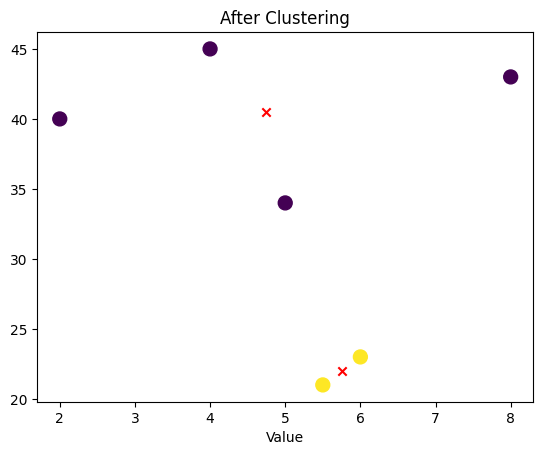

In [107]:
plt.figure()
plt.scatter(x=df["study_hours"],y=df["marks"], c=df["cluster"],s=100)
plt.scatter(centroids[:, 0],centroids[:,1], marker='x',c="red")
plt.title("After Clustering")
plt.xlabel("Value")
plt.show()

In [84]:
print(classification_report(df['result'],df['y_pred']))

              precision    recall  f1-score   support

         0.0       0.50      0.67      0.57         3
         1.0       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6

